# KNN — K Nearest Neighbors

In [ ]:
The Story First 📖

New student joins your college
You don't know if they're studious or not

What do you do?
→ look at their 5 closest friends!
→ if 4 out of 5 friends are studious
→ they're probably studious too!

"Tell me who your neighbors are
and I'll tell you who you are!"

That's exactly KNN! 😄

In [ ]:
How KNN Works — Step by Step:
Step 1 → store ALL training data
         (no actual training happens!)

Step 2 → new data point comes in

Step 3 → calculate distance to
         every training point

Step 4 → find K nearest neighbors
         (K=5 means 5 closest points)

Step 5 → majority vote of K neighbors
         → final prediction!

In [ ]:



Distance — How KNN Measures Closeness:

Most common → Euclidean Distance:

Like measuring straight line distance!

Point A = (2, 3)   (age=2, salary=3)
Point B = (5, 7)   (age=5, salary=7)

Distance = √((5-2)² + (7-3)²)
         = √(9 + 16)
         = √25
         = 5

In [ ]:
Visualizing:

     7| B(5,7)
     6|    /
     5|   /  distance=5
     4|  /
     3| A(2,3)
      |_________
        2 3 4 5

In [ ]:
Effect of K — Most Important Concept!



K=1 → only 1 nearest neighbor
    → very sensitive to noise
    → overfits easily! ❌

K=5 → 5 nearest neighbors
    → balanced ✅ (default)

K=20 → 20 nearest neighbors
     → too many, misses patterns
     → underfits! ❌

Visual:

K=1 (overfit):          K=5 (balanced):
very jagged boundary    smooth boundary ✅

In [ ]:
How to choose best K?

→ try multiple K values
→ pick K with best test accuracy
→ usually odd number (avoid ties!)
→ common values: 3, 5, 7, 11

# Very Important — Feature Scaling!

In [ ]:
KNN uses DISTANCE to find neighbors
Distance is affected by scale of features!

Example:
age    = [22, 25, 47]      (range 0-100)
salary = [15000, 80000]    (range 0-100000)

salary dominates distance!
age becomes useless!

Solution → Scale features first!

# Two scaling methods:

In [ ]:

from sklearn.preprocessing import StandardScaler, MinMaxScaler

# StandardScaler → mean=0, std=1
# use when data has outliers
scaler = StandardScaler()

# MinMaxScaler → range 0 to 1
# use when no outliers
scaler = MinMaxScaler()

In [8]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score , confusion_matrix , classification_report


# data
data = {
    "age"    : [22,25,47,52,46,56,55,60,62,61,
                18,28,27,29,49,55,25,58,19,40],
    "salary" : [15,18,60,80,55,90,85,95,100,98,
                12,20,22,25,65,88,19,92,14,45],
    "bought" : [0,0,1,1,1,1,0,1,1,1,
                0,0,0,0,1,1,0,1,0,1]
}

df= pd.DataFrame(data)

X=df[["age","salary"]]
y=df["bought"]

X_train, X_test, y_train, y_test = train_test_split(  
   X, y, test_size=0.2, random_state=42)  


#    step 1 - scale features very imp for knn
scaler= StandardScaler()
X_train_scaled= scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# fit_transform on train → learns mean and std
# transform on test      → uses same mean and std!

# STEP 2 — Create model
model = KNeighborsClassifier(
    n_neighbors=5, # K value
    metric="euclidean",# distance formula
    weights="uniform",# all neighbors equal weight
    algorithm="auto",# how to find neighbors
    n_jobs=-1 # use all CPU cores
)

# step -3 train
model.fit(X_train_scaled,y_train)


# STEP 4 — Predict
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)


# STEP 5 — Evaluate
train_acc = accuracy_score(y_train,
            model.predict(X_train_scaled))
test_acc  = accuracy_score(y_test, y_pred)


print(" train accuracy :", train_acc )
print("test accuracy :", test_acc)
print("Difference    :", round(train_acc-test_acc, 2))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

 train accuracy : 0.9375
test accuracy : 1.0
Difference    : -0.06

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



# Parameters Explained

In [ ]:
n_neighbors=5:

K = how many neighbors to check

K=1  → overfit ❌
K=5  → balanced ✅ (default)
K=20 → underfit ❌

Always try odd numbers!
3, 5, 7, 9, 11...

In [ ]:
metric="euclidean":

how to calculate distance

"euclidean" → straight line distance ✅ (default)
"manhattan" → grid-like distance
              (like walking city blocks)
"minkowski" → generalized distance

euclidean works for most cases! ✅

In [ ]:
weights="uniform":

"uniform"  → all K neighbors equal vote ✅
"distance" → closer neighbors get more vote
             (more weight to nearby points)

Try both and compare!

In [ ]:
algorithm="auto":

how model searches for neighbors

"auto"     → sklearn picks best automatically ✅
"kd_tree"  → good for low dimensions
"ball_tree"→ good for high dimensions
"brute"    → checks every point (slow!)

always use "auto"! ✅

# Finding Best K — Very Important!

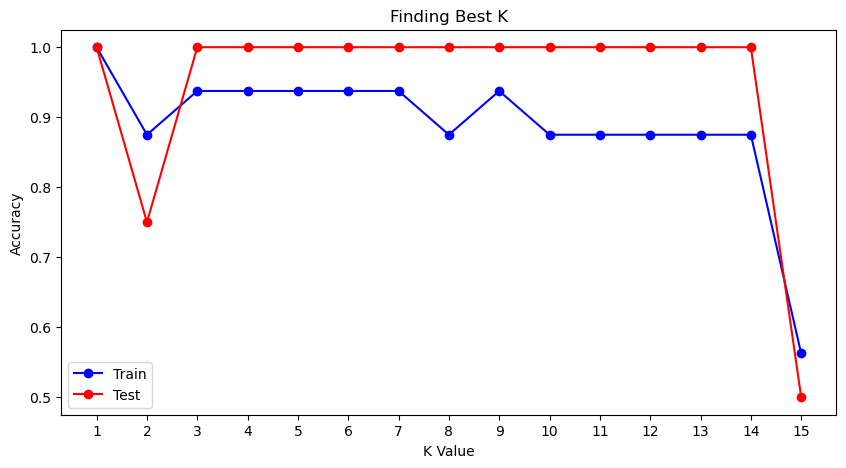

Best K: 1
Best Test Accuracy: 1.0


In [10]:
# try K from 1 to 20
train_scores = []
test_scores  = []
k_values     = range(1, 16)

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    train_scores.append(accuracy_score(y_train,
                        knn.predict(X_train_scaled)))
    test_scores.append(accuracy_score(y_test,
                       knn.predict(X_test_scaled)))

# plot
plt.figure(figsize=(10, 5))
plt.plot(k_values, train_scores,
         label="Train", color="blue", marker="o")
plt.plot(k_values, test_scores,
         label="Test",  color="red",  marker="o")
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("Finding Best K")
plt.legend()
plt.xticks(k_values)
plt.show()

# best K
best_k = k_values[test_scores.index(max(test_scores))]
print("Best K:", best_k)
print("Best Test Accuracy:", max(test_scores))

# Confusion Matrix Plot:

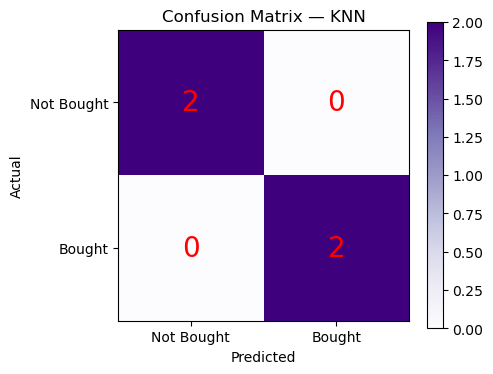

In [11]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap="Purples")
plt.colorbar()
plt.title("Confusion Matrix — KNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0,1], ["Not Bought", "Bought"])
plt.yticks([0,1], ["Not Bought", "Bought"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i,j],
                ha="center", va="center",
                color="red", fontsize=20)
plt.tight_layout()
plt.show()

In [ ]:
KNN vs Random Forest vs Decision Tree:

              KNN      Decision Tree   Random Forest
──────────────────────────────────────────────────
Training      None!    Fast            Slow
Prediction    Slow     Fast            Medium
Scaling       Must!    Not needed      Not needed
Interpretable Easy     Easy            Hard
Overfitting   K=1 ❌   max_depth ❌    Low ✅
Large data    Slow ❌   Fast ✅         Fast ✅

Notes Summary 📝

In [ ]:
KNN:
→ no actual training! stores all data
→ prediction = find K nearest neighbors
→ majority vote = final answer

Key concept:
→ MUST scale features before KNN!
→ distance is affected by scale

Parameters:
→ n_neighbors = K value (5 default)
→ metric      = distance formula
→ weights     = uniform or distance

Choosing K:
→ try K = 1 to 20
→ plot train vs test accuracy
→ pick K with best test accuracy
→ always use odd K!

When to use KNN:
→ small dataset
→ simple baseline model
→ when you need quick results

When NOT to use:
→ large dataset (slow prediction!)
→ high dimensional data
→ when features have very different scales
   (without scaling!)

In [ ]:
Plot 1 — Finding Best K:
K=1  → test=1.0, train=1.0  → perfect but suspicious!
K=2  → test=0.75 → drops! (even number, ties!)
K=3  → test=1.0  → perfect! ✅
K=3 to K=14 → test stays at 1.0 → stable! ✅
K=15 → both drop badly → too many neighbors!


Best K = 3 ✅


Why not K=1?
→ K=1 overfits on real world data
→ K=3 is more stable and reliable!

Why K=2 dropped?
→ even number → ties happen!
→ always use odd K! 💡



Plot 2 — Confusion Matrix:

TN = 2 ✅  FP = 0 ✅
FN = 0 ✅  TP = 2 ✅

Perfect model! Zero mistakes! 🎯